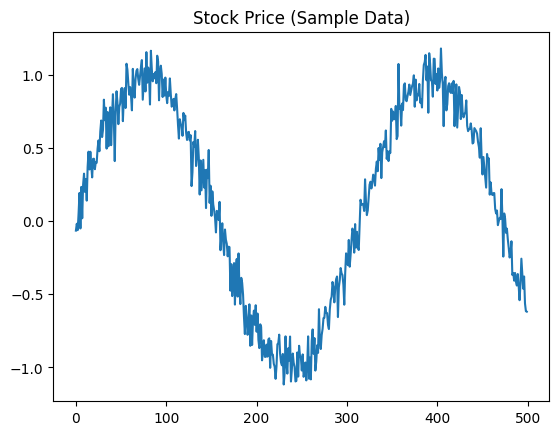

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic stock data
time = np.arange(0, 500)
price = np.sin(0.02*time) + np.random.normal(0, 0.1, 500)

plt.plot(price)
plt.title("Stock Price (Sample Data)")
plt.show()

In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
price_scaled = scaler.fit_transform(price.reshape(-1,1))

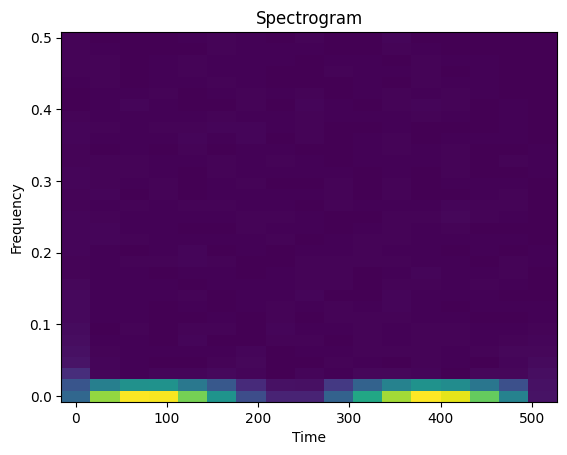

In [3]:
from scipy.signal import stft

f, t, Zxx = stft(price_scaled.flatten(), nperseg=64)

plt.pcolormesh(t, f, abs(Zxx))
plt.title("Spectrogram")
plt.ylabel("Frequency")
plt.xlabel("Time")
plt.show()

In [4]:
X = []
y = []

spec = abs(Zxx)

for i in range(spec.shape[1] - 1):
    X.append(spec[:, i:i+1])
    y.append(spec[0, i+1])

X = np.array(X)
y = np.array(y)

# Reshape for CNN
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16, 33, 1, 1)
y shape: (16,)


In [5]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Conv2D(32, (3,1), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    layers.MaxPooling2D((2,1)),

    layers.Conv2D(64, (3,1), activation='relu'),
    layers.MaxPooling2D((2,1)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

2026-03-29 17:14:30.929900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774804471.177465      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774804471.246787      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774804471.791410      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774804471.791468      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774804471.791471      17 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 1, 32)      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 1, 64)      │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,041 (121.25 KB)

 Trainable params: 31,041 (121.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.fit(X, y, epochs=5, batch_size=8)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.4205
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3748
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3176
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3127
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2503


In [7]:
from sklearn.metrics import mean_squared_error

pred = model.predict(X)
mse = mean_squared_error(y, pred)

print("MSE:", mse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
MSE: 0.2264378657777712
